# Pre-training Critic Values

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import RGCNConv, global_mean_pool
from sklearn.model_selection import train_test_split

##### 1. Load Dataset

In [2]:
import os
import numpy as np
import torch
from torch_geometric.data import Data

DATASET_PATH = "dataset_3Way"
NUM_EPISODES = 100

graph_list = []
all_returns = []

# 1. Collect all returns for normalization
episode_data = []
print("Loading dataset...")
for ep in range(NUM_EPISODES):
    data = np.load(f"{DATASET_PATH}/episode_{ep}.npy", allow_pickle=True).item()
    episode_data.append(data)
    all_returns.append(data["returns"])

all_returns = np.concatenate(all_returns)
mean = np.mean(all_returns)
std = np.std(all_returns)

# 2. Build graph list with normalized returns
for data in episode_data:
    nodes = data["nodes"]      # (T, N, F)
    edges = data["edges"]      # (T, R, N, N)
    returns = data["returns"]  # (T,)
    T, N, F_dim = nodes.shape
    R = edges.shape[1]

    for t in range(T):
        x = torch.tensor(nodes[t], dtype=torch.float32)  # (N, F)
        # Normalize return
        y = torch.tensor([(returns[t] - mean) / std], dtype=torch.float32)

        edge_index_list = []
        edge_type_list = []

        for r in range(R):
            adj = edges[t, r]  # (N, N)
            src, dst = np.where(adj == 1)
            for s, d in zip(src, dst):
                edge_index_list.append([s, d])
                edge_type_list.append(r)

        if len(edge_index_list) == 0:
            continue

        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_type = torch.tensor(edge_type_list, dtype=torch.long)

        graph = Data(
            x=x,
            edge_index=edge_index,
            edge_type=edge_type,
            y=y
        )

        graph_list.append(graph)

print("Total graphs:", len(graph_list))

Loading dataset...
Total graphs: 20000


##### 2. Prepare Data for Training

In [3]:
train_graphs, test_graphs = train_test_split(
    graph_list, test_size=0.2, random_state=42
)

train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=64)

# Shape info
print("Example graph:")
print("Node features shape:", graph_list[0].x.shape)
print("Edge index shape:", graph_list[0].edge_index.shape)
print("Edge type shape:", graph_list[0].edge_type.shape)
print("Target shape:", graph_list[0].y.shape)

Example graph:
Node features shape: torch.Size([3, 12])
Edge index shape: torch.Size([2, 4])
Edge type shape: torch.Size([4])
Target shape: torch.Size([1])


##### 3. Build GCN model

In [4]:
class RGCNCritic(nn.Module):
    def __init__(self, in_channels, hidden_dim, num_relations):
        super().__init__()
        self.conv1 = RGCNConv(in_channels, hidden_dim, num_relations)
        self.conv2 = RGCNConv(hidden_dim, hidden_dim, num_relations)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x, edge_index, edge_type, batch):
        x = F.relu(self.conv1(x, edge_index, edge_type))
        x = F.relu(self.conv2(x, edge_index, edge_type))
        x = global_mean_pool(x, batch)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = RGCNCritic(
    in_channels=F_dim,
    hidden_dim=64,
    num_relations=R
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

print(model)


cuda
RGCNCritic(
  (conv1): RGCNConv(12, 64, num_relations=3)
  (conv2): RGCNConv(64, 64, num_relations=3)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


##### 4. Train the model

In [5]:
EPOCHS = 100
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_type, batch.batch)
        loss = criterion(out.squeeze(), batch.y.squeeze())
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_type, batch.batch)
            loss = criterion(out.squeeze(), batch.y.squeeze())
            val_loss += loss.item()

    val_loss /= len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 1/100 | Train: 1.8055 | Val: 0.6798
Epoch 2/100 | Train: 0.6405 | Val: 0.5740
Epoch 3/100 | Train: 0.5693 | Val: 0.5670
Epoch 4/100 | Train: 0.5529 | Val: 0.5554
Epoch 5/100 | Train: 0.5440 | Val: 0.4966
Epoch 6/100 | Train: 0.5514 | Val: 0.7548
Epoch 7/100 | Train: 0.5278 | Val: 0.5157
Epoch 8/100 | Train: 0.5148 | Val: 0.4737
Epoch 9/100 | Train: 0.5010 | Val: 0.4907
Epoch 10/100 | Train: 0.5101 | Val: 0.6175
Epoch 11/100 | Train: 0.4967 | Val: 0.4762
Epoch 12/100 | Train: 0.4948 | Val: 0.4745
Epoch 13/100 | Train: 0.4891 | Val: 0.4674
Epoch 14/100 | Train: 0.4812 | Val: 0.4801
Epoch 15/100 | Train: 0.4761 | Val: 0.5161
Epoch 16/100 | Train: 0.4776 | Val: 0.4756
Epoch 17/100 | Train: 0.4766 | Val: 0.4543
Epoch 18/100 | Train: 0.4681 | Val: 0.4454
Epoch 19/100 | Train: 0.4645 | Val: 0.4624
Epoch 20/100 | Train: 0.4569 | Val: 0.4260
Epoch 21/100 | Train: 0.4539 | Val: 0.4396
Epoch 22/100 | Train: 0.4478 | Val: 0.4301
Epoch 23/100 | Train: 0.4454 | Val: 0.4296
Epoch 24/100 | Train

##### 5. Visualize Losses

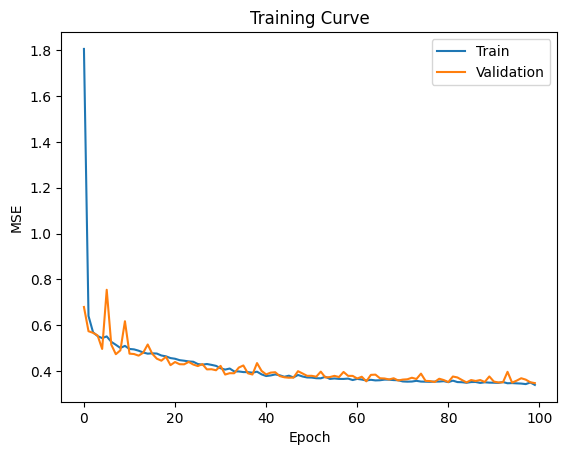

In [6]:
# =========================================================
# 5️⃣ VISUALIZE TRAINING
# =========================================================

plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()  

In [7]:
# Collect predictions and ground truth from the test set
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_type, batch.batch)
        y_true.append(batch.y.cpu().numpy())
        y_pred.append(out.cpu().numpy())

y_true = np.concatenate(y_true).flatten()
y_pred = np.concatenate(y_pred).flatten()

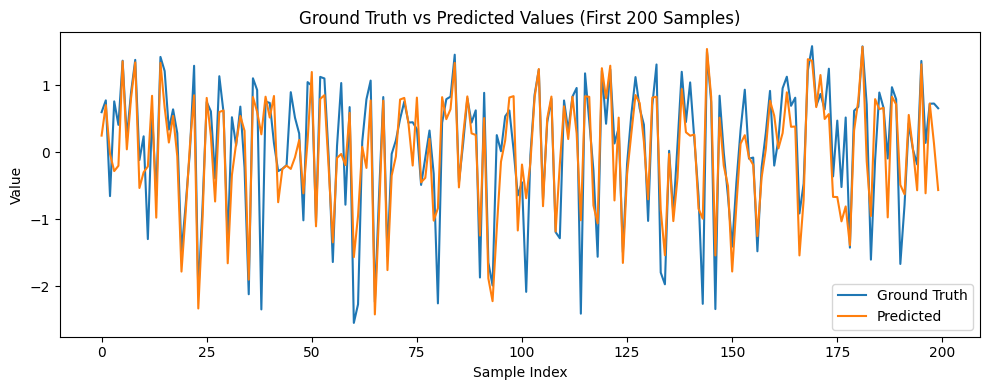

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(y_true[:200], label="Ground Truth")
plt.plot(y_pred[:200], label="Predicted")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Ground Truth vs Predicted Values (First 200 Samples)")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Save Training Logs as CSV
import pandas as pd
log_df = pd.DataFrame({
    "epoch": list(range(1, EPOCHS + 1)),
    "train_loss": train_losses,
    "val_loss": val_losses
})
log_df.to_csv("3_Value_Learning_Logs_3_WAY.csv", index=False)

In [10]:
os.makedirs("Models", exist_ok=True)

torch.save(model.state_dict(), "./Models/rgcn_critic_3WAY.pth")
print("3 WAY Model saved.")


3 WAY Model saved.


In [11]:
# Evaluate and print final test MSE
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_type, batch.batch)
        loss = criterion(out.squeeze(), batch.y.squeeze())
        test_loss += loss.item()
test_loss /= len(test_loader)
print(f"Final Test MSE: {test_loss:.4f}")

Final Test MSE: 0.3477


##### 6. Export R-Lib Compatible Module

In [12]:

class RLlibRGCNWrapper(nn.Module):
    def __init__(self, rgcn_model):
        super().__init__()
        self.model = rgcn_model

    def forward(self, input_dict):
        x = input_dict["x"]
        edge_index = input_dict["edge_index"]
        edge_type = input_dict["edge_type"]
        batch = input_dict["batch"]

        value = self.model(x, edge_index, edge_type, batch)
        return value

torch.save(model, "./Models/rgcn_critic_full_model_3_Way.pt")

print("RLlib compatible model saved.")

RLlib compatible model saved.


##### PAPER PLOTS

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# -------------------------------------------------
# LOAD DATA
# -------------------------------------------------
df = pd.read_csv("resnet50training_history.csv")

epochs = np.arange(len(df))
train_loss = df['loss'].values
val_loss   = df['val_loss'].values

# -------------------------------------------------
# LOG NORMALIZATION
# -------------------------------------------------
train_log = np.log1p(train_loss)
val_log   = np.log1p(val_loss)

train_norm = (train_log - train_log.min()) / (train_log.max() - train_log.min())
val_norm   = (val_log   - val_log.min())   / (val_log.max()   - val_log.min())

# -------------------------------------------------
# GAUSSIAN SURFACE
# -------------------------------------------------
scale = np.linspace(-1, 1, 160)
E, S = np.meshgrid(epochs, scale)

sigma = 0.35

Z_train = np.exp(-(S**2)/(2*sigma**2)) * (train_norm ** 0.7)
Z_val   = np.exp(-(S**2)/(2*sigma**2)) * (val_norm ** 0.7)

# -------------------------------------------------
# COMMON MARKERS
# -------------------------------------------------
markers = [0, 24, 49, 74, 99]
markers = [m for m in markers if m < len(epochs)]

first_idx = markers[0]
last_idx  = markers[-1]

# =================================================
# TRAINING PLOT
# =================================================
fig_train = go.Figure()

fig_train.add_trace(go.Surface(
    x=E, y=S, z=Z_train,
    colorscale='Viridis',
    showscale=True,
    opacity=0.97,
    contours={"z": {"show": True,
                    "start": 0,
                    "end": Z_train.max(),
                    "size": 0.05,
                    "color": "white",
                    "width": 1.2}}
))

# Text annotations (NO SHADOW)
for i, m in enumerate(markers):

    z_val = (train_norm[m] ** 0.7)

    y_wave = 0.09 * np.sin(i * 1.3)
    z_wave = 0.05 * np.sin(i * 1.1)
    lift = 0.11 + z_wave + 0.04 * z_val

    color = "red" if m in [first_idx, last_idx] else "black"

    fig_train.add_trace(go.Scatter3d(
        x=[m],
        y=[y_wave],
        z=[z_val + lift],
        mode='text',
        text=[f"{train_loss[m]:.3f}"],
        textfont=dict(color=color, size=14, family="Arial Black"),
        showlegend=False
    ))

fig_train.update_layout(
    title="Loss QVQC-RNet50 - Training",
    title_x=0.5,
    scene=dict(
        xaxis_title="Epochs",
        yaxis_title="Norm. Scale",
        zaxis_title="Norm. Loss",
        aspectmode='cube',
        camera=dict(eye=dict(x=1.8, y=1.8, z=0.6)),
        bgcolor='white'
    ),
    height=700,
    width=900,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig_train.show()

# =================================================
# VALIDATION PLOT
# =================================================
fig_val = go.Figure()

fig_val.add_trace(go.Surface(
    x=E, y=S, z=Z_val,
    colorscale='Plasma',
    showscale=True,
    opacity=0.97,
    contours={"z": {"show": True,
                    "start": 0,
                    "end": Z_val.max(),
                    "size": 0.05,
                    "color": "white",
                    "width": 1.2}}
))

for i, m in enumerate(markers):

    z_val = (val_norm[m] ** 0.7)

    y_wave = 0.09 * np.sin(i * 1.3)
    z_wave = 0.05 * np.sin(i * 1.1)
    lift = 0.11 + z_wave + 0.04 * z_val

    color = "red" if m in [first_idx, last_idx] else "black"

    fig_val.add_trace(go.Scatter3d(
        x=[m],
        y=[y_wave],
        z=[z_val + lift],
        mode='text',
        text=[f"{val_loss[m]:.3f}"],
        textfont=dict(color=color, size=14, family="Arial Black"),
        showlegend=False
    ))

fig_val.update_layout(
    title="Loss QVQC-RNet50 - Validation",
    title_x=0.5,
    scene=dict(
        xaxis_title="Epochs",
        yaxis_title="Norm. Scale",
        zaxis_title="Norm. Loss",
        aspectmode='cube',
        camera=dict(eye=dict(x=1.8, y=1.8, z=0.6)),
        bgcolor='white'
    ),
    height=700,
    width=900,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig_val.show()


# Paper Works

/tmp/ipykernel_8728/300141222.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./Models/rgcn_critic_3WAY.pth", map_location=device))


R² Score: 0.655


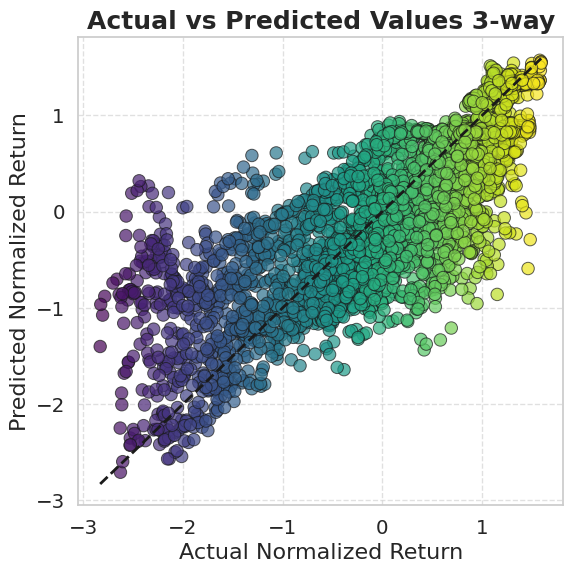

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# 1. Reload the model architecture and weights
model = RGCNCritic(in_channels=F_dim, hidden_dim=64, num_relations=R).to(device)
model.load_state_dict(torch.load("./Models/rgcn_critic_3WAY.pth", map_location=device))
model.eval()

# 2. Predict on the test set
y_true = []
y_pred = []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_type, batch.batch)
        y_true.append(batch.y.cpu().numpy())
        y_pred.append(out.cpu().numpy())

y_true = np.concatenate(y_true).flatten()
y_pred = np.concatenate(y_pred).flatten()

# 3. Stylish Seaborn scatter plot
sns.set(style="whitegrid", font_scale=1.3)
plt.figure(figsize=(6,6))

# Use color mapping for density
sns.scatterplot(x=y_true, y=y_pred, hue=y_true, palette="viridis", edgecolor='k', s=80, alpha=0.7, legend=False)

# Diagonal reference line
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2, label='Ideal Fit')

plt.xlabel('Actual Normalized Return', fontsize=16)
plt.ylabel('Predicted Normalized Return', fontsize=16)
plt.title('Actual vs Predicted Values 3-way', fontsize=18, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

'''
# R² annotation
r2 = r2_score(y_true, y_pred)
plt.text(0.05, 0.95, f'$R^2$ = {r2:.3f}', transform=plt.gca().transAxes, fontsize=15, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))
'''
r2 = r2_score(y_true, y_pred)
print(f"R² Score: {r2:.3f}")

plt.savefig("./Extended_Work_Plots/Actual_vs_Predicted_3_Way.png", dpi=200)

plt.show()